## Sequential node

```md
Q:  1. Accept username, age, and skill list
    2. Pass the state through 3 nodes
        - First Node: Personalizes the name field with greeting
        - Second Node: Describes the users age
        - List the users age in formatted string
    3. Final output will be look like
        "Linda , Welcome to our system! You are 31 year old and your skills are : Python , java etc"
```

In [4]:
from langgraph.graph import StateGraph
from typing import List, TypedDict
from IPython.display import Image, display

In [6]:
class AgentState(TypedDict):
    username: str
    age: str
    skills: List[str]
    result: str

In [8]:
def greeting_node(state: AgentState)->AgentState:
    """You are greeter"""
    state["result"] = f"{state['username']}, Welcome to our system!!! "
    return state

In [9]:
def age_telling_node(state: AgentState)->AgentState:
    """ You are age teller"""
    state["result"] = state["result"] + f"You are {state['age']} years old"
    return state


In [21]:
def skill_telling_node(state: AgentState)->AgentState:
    """ You are skill"""
    state["result"] = state["result"] + f" and your skills are {",".join(state['skills'])}."
    return state


In [22]:
graph = StateGraph(AgentState)
graph.add_node("greeting", greeting_node)
graph.add_node("age", age_telling_node)
graph.add_node("skill", skill_telling_node)
graph.add_edge("greeting", "age")
graph.add_edge("age", "skill")
graph.set_entry_point("greeting")
graph.set_finish_point("age")

In [23]:
app = graph.compile()

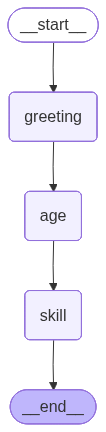

In [24]:
display(Image(app.get_graph().draw_mermaid_png()))

In [25]:
answers = app.invoke({"username":"Nikhil","age":35, "skills":["python","data"]})
answers

{'username': 'Nikhil',
 'age': 35,
 'skills': ['python', 'data'],
 'result': 'Nikhil, Welcome to our system!!! You are 35 years old and your skills are python,data.'}